# Feature engineering notebook

In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
# Loading data
df = pd.read_csv(r"C:\Users\diego\Documents\ml_projects\iris\IRIS_cleaned.csv")

## Feature extraction
- Ratio of features
- Product of features
- Difference of features

In [3]:
# Add ratio column
df['sepal_ratio'] = df['sepal_length'] / df['sepal_width']

In [4]:
# Add petal ratio column
df['petal_ratio'] = df['petal_length'] / df['petal_width']

In [5]:
# Add sepal product column
df['sepal_product'] = df['sepal_length'] * df['sepal_width']

In [6]:
# Add petal product column
df['petal_product'] = df['petal_length'] * df['petal_width']

In [7]:
# Add sepal difference column
df['sepal_difference'] = df['sepal_length'] - df['sepal_width']

In [8]:
# Add petal difference column
df['petal_difference'] = df['petal_length'] - df['petal_width']

In [9]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species,sepal_ratio,petal_ratio,sepal_product,petal_product,sepal_difference,petal_difference
0,5.1,3.5,1.4,0.2,Iris-setosa,1.457143,7.0,17.85,0.28,1.6,1.2
1,4.9,3.0,1.4,0.2,Iris-setosa,1.633333,7.0,14.70,0.28,1.9,1.2
2,4.7,3.2,1.3,0.2,Iris-setosa,1.468750,6.5,15.04,0.26,1.5,1.1
3,4.6,3.1,1.5,0.2,Iris-setosa,1.483871,7.5,14.26,0.30,1.5,1.3
4,5.0,3.6,1.4,0.2,Iris-setosa,1.388889,7.0,18.00,0.28,1.4,1.2


In [10]:
# Drop label column
df_features = df.drop(columns=['species'])

## Feature Selection

In [11]:
# Variance of features
print("Variance of features:\n", df_features.var())

Variance of features:
 sepal_length         0.687407
sepal_width          0.190977
petal_length         3.094471
petal_width          0.574373
sepal_ratio          0.160035
petal_ratio          5.588961
sepal_product       11.453389
petal_product       22.130801
sepal_difference     0.957602
petal_difference     1.104110
dtype: float64


### Correlation analysis

In [12]:
# Covariance matrix of features
print("\nCovariance matrix of features:\n", df_features.corr())


Covariance matrix of features:
                   sepal_length  sepal_width  petal_length  petal_width  \
sepal_length          1.000000    -0.109321      0.871305     0.817058   
sepal_width          -0.109321     1.000000     -0.421057    -0.356376   
petal_length          0.871305    -0.421057      1.000000     0.961883   
petal_width           0.817058    -0.356376      0.961883     1.000000   
sepal_ratio           0.725953    -0.746349      0.834384     0.748146   
petal_ratio          -0.573256     0.354257     -0.701865    -0.751847   
sepal_product         0.680811     0.648061      0.363047     0.372439   
petal_product         0.856983    -0.278412      0.957473     0.980094   
sepal_difference      0.896076    -0.539201      0.926252     0.851407   
petal_difference      0.869360    -0.447862      0.980356     0.889051   

                  sepal_ratio  petal_ratio  sepal_product  petal_product  \
sepal_length         0.725953    -0.573256       0.680811       0.856983   


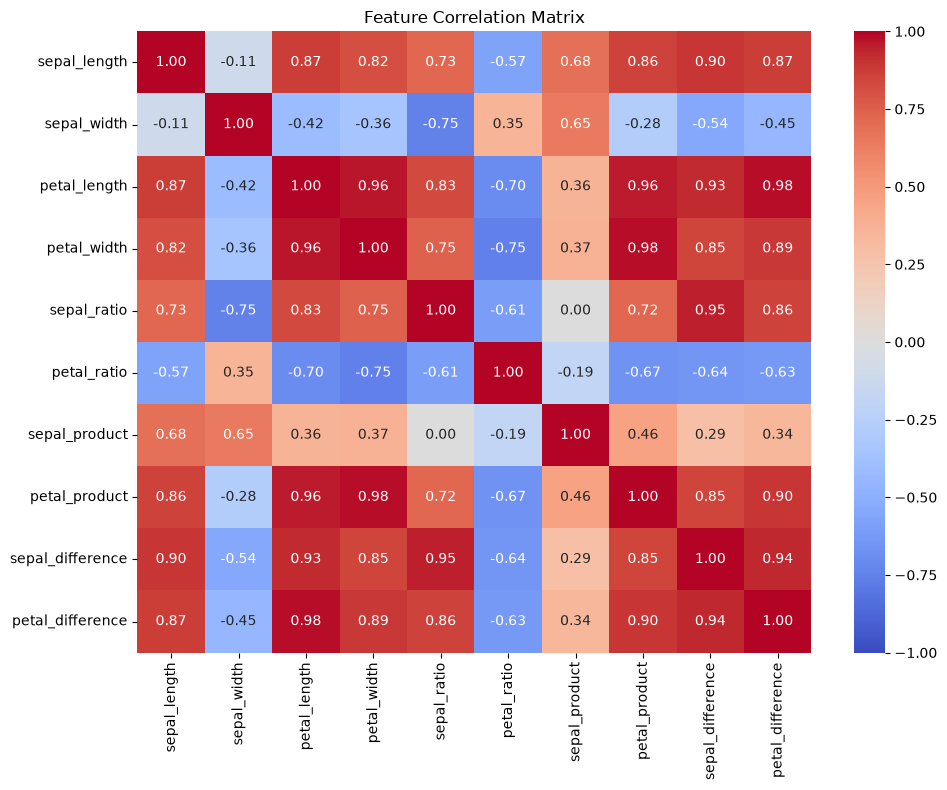

In [13]:
# Plotting correlation heatmap

corr = df_features.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)

plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [14]:
# Make a list of correlation pairs with the upper triangle of the correlation matrix
corr_pairs = (corr.where(np.triu(np.ones(corr.shape),k=1).astype(bool)).stack().reset_index().dropna())

In [15]:
# Create a DataFrame with correlation pairs and their values
corr_pairs.columns = ['Feature_1', 'Feature_2', 'Correlation']

# Add a column for absolute correlation values
corr_pairs['abs_correlation'] = corr_pairs['Correlation'].abs()

# Sort the DataFrame by absolute correlation values in descending order
corr_pairs = corr_pairs.sort_values(by='abs_correlation', ascending=False)

In [16]:
print(corr_pairs)

           Feature_1         Feature_2  Correlation  abs_correlation
29      petal_length  petal_difference     0.980356         0.980356
37       petal_width     petal_product     0.980094         0.980094
23      petal_length       petal_width     0.961883         0.961883
27      petal_length     petal_product     0.957473         0.957473
48       sepal_ratio  sepal_difference     0.948370         0.948370
89  sepal_difference  petal_difference     0.936575         0.936575
28      petal_length  sepal_difference     0.926252         0.926252
8       sepal_length  sepal_difference     0.896076         0.896076
79     petal_product  petal_difference     0.896025         0.896025
39       petal_width  petal_difference     0.889051         0.889051
2       sepal_length      petal_length     0.871305         0.871305
9       sepal_length  petal_difference     0.869360         0.869360
49       sepal_ratio  petal_difference     0.857254         0.857254
7       sepal_length     petal_pro

In [17]:
corr_pairs.describe()

,Correlation,abs_correlation
count,45.000000,45.000000
mean,0.315962,0.656532
std,0.637563,0.260301
min,-0.751847,0.000632
25%,-0.356376,0.447862
50%,0.648061,0.722458
75%,0.869360,0.869360
max,0.980356,0.980356


In [18]:
threshold = 0.7

strong = corr_pairs[corr_pairs['abs_correlation']>=threshold]

print("Number of strong correlations:", len(strong))

feature_counts = pd.concat([strong['Feature_1'], strong['Feature_2']]).value_counts()

print("Feature counts in strong correlations:\n", feature_counts)

Number of strong correlations: 24
Feature counts in strong correlations:
 petal_length        7
petal_width         7
sepal_ratio         7
sepal_difference    6
sepal_length        6
petal_product       6
petal_difference    6
petal_ratio         2
sepal_width         1
Name: count, dtype: int64


In [19]:
mean_corr = {}

for feature in corr.columns:
    values = corr.loc[feature].drop(feature).abs() # Exclude self-correlation
    mean_corr[feature] = values.mean()

mean_corr = pd.Series(mean_corr).sort_values(ascending=False)

print("Mean correlation of features:\n", mean_corr)

Mean correlation of features:
 petal_length        0.779736
sepal_difference    0.764401
petal_difference    0.760930
petal_width         0.747589
petal_product       0.740900
sepal_length        0.711125
sepal_ratio         0.687676
petal_ratio         0.568723
sepal_width         0.433433
sepal_product       0.370806
dtype: float64


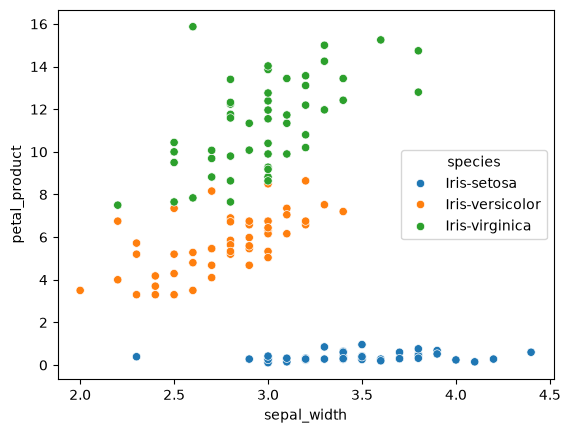

In [20]:
# Create a scatter plot, to visualize the pair of features correlation
sns.scatterplot(data=df_features, x='sepal_width', y='petal_product', hue=df['species'])

plt.show()

## Mutual information analysis

In [21]:
# Mutual information between features and target variable
from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(df_features, df['species'])
print("\nMutual Information scores:\n", mi_scores)


Mutual Information scores:
 [0.47032552 0.2687887  0.99875703 0.98439386 0.62226583 0.63242026
 0.01544389 1.03766847 0.7245819  0.77362631]


array([[<Axes: title={'center': 'sepal_length'}>,
        <Axes: title={'center': 'sepal_width'}>,
        <Axes: title={'center': 'petal_length'}>],
       [<Axes: title={'center': 'petal_width'}>,
        <Axes: title={'center': 'sepal_ratio'}>,
        <Axes: title={'center': 'petal_ratio'}>],
       [<Axes: title={'center': 'sepal_product'}>,
        <Axes: title={'center': 'petal_product'}>,
        <Axes: title={'center': 'sepal_difference'}>],
       [<Axes: title={'center': 'petal_difference'}>, <Axes: >, <Axes: >]],
      dtype=object)

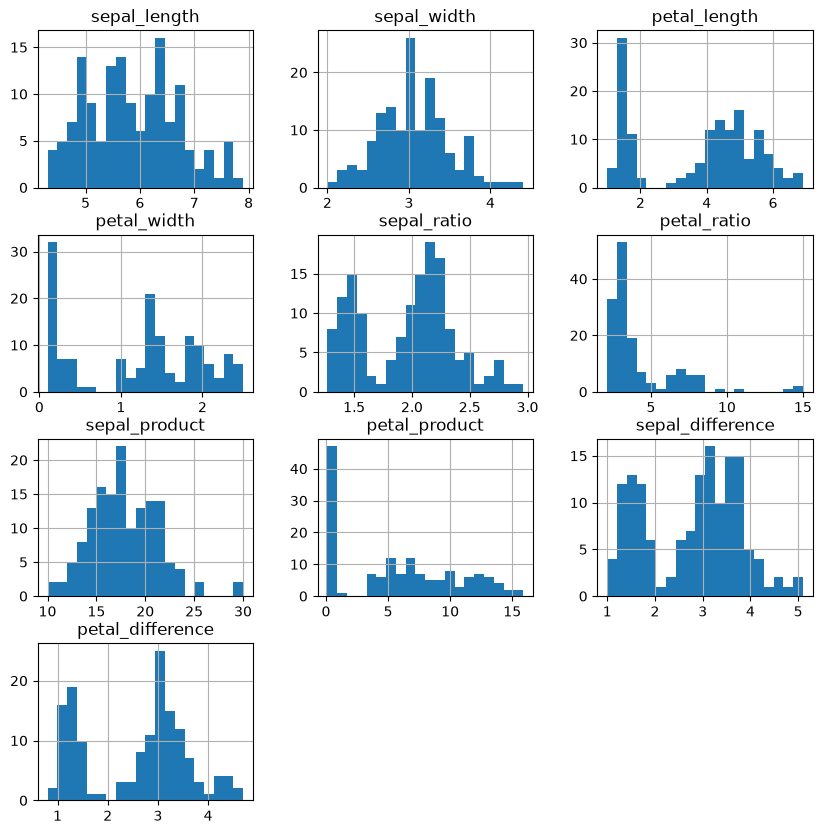

In [22]:
# Plot histogram of features
import matplotlib.pyplot as plt

df_features.hist(bins=20, figsize=(10, 10))